Parsing circuit

In [2]:
from pathlib import Path
import re
import time
import random

import pandas as pd
import numpy as np

# ============================================================
# C880 Scenario 1 Configuration
# ============================================================

BENCH_FILE = Path("../fsim-contest.github/fsim-contest.github/data.nogit/c880.bench")
FAULT_FILE = Path("c880_equivalence_collapsed_saf.txt")

N_VECTORS = 1024

RANDOM_SEED = 42

# C880 is expected to have:
EXPECTED_PI_COUNT = 60
EXPECTED_PO_COUNT = 26

class Gate:
    def __init__(self, output, gate_type, inputs):
        self.output = str(output)
        self.gate_type = gate_type.upper()
        self.inputs = [str(x) for x in inputs]

    def __repr__(self):
        return f"Gate({self.output} = {self.gate_type}({', '.join(self.inputs)}))"


class Circuit:
    def __init__(self):
        self.inputs = []
        self.outputs = []
        self.gates = []

        # Quick lookup
        self.gate_by_output = {}

        # Evaluation order
        self.eval_order = []

    def __repr__(self):
        return (
            f"Circuit("
            f"PIs={len(self.inputs)}, "
            f"POs={len(self.outputs)}, "
            f"gates={len(self.gates)})"
        )

def parse_bench_file(filename):
    """
    Parse an ISCAS .bench combinational circuit.

    Returns
    -------
    Circuit
        Parsed circuit representation.
    """

    circuit = Circuit()

    input_re = re.compile(r"^\s*INPUT\s*\(\s*([^)]+)\s*\)\s*$", re.IGNORECASE)
    output_re = re.compile(r"^\s*OUTPUT\s*\(\s*([^)]+)\s*\)\s*$", re.IGNORECASE)

    gate_re = re.compile(
        r"^\s*([^\s=]+)\s*=\s*([A-Za-z0-9_]+)\s*\((.*?)\)\s*$"
    )

    with open(filename, "r") as f:
        for line_number, raw_line in enumerate(f, start=1):

            # Remove comments
            line = raw_line.split("#", 1)[0].strip()

            if not line:
                continue

            # INPUT
            match = input_re.match(line)
            if match:
                signal = match.group(1).strip()
                circuit.inputs.append(signal)
                continue

            # OUTPUT
            match = output_re.match(line)
            if match:
                signal = match.group(1).strip()
                circuit.outputs.append(signal)
                continue

            # Gate assignment
            match = gate_re.match(line)
            if match:
                output_signal = match.group(1).strip()
                gate_type = match.group(2).strip().upper()

                input_string = match.group(3).strip()

                if input_string:
                    gate_inputs = [
                        x.strip()
                        for x in input_string.split(",")
                    ]
                else:
                    gate_inputs = []

                gate = Gate(
                    output=output_signal,
                    gate_type=gate_type,
                    inputs=gate_inputs
                )

                circuit.gates.append(gate)
                circuit.gate_by_output[output_signal] = gate

                continue

            raise ValueError(
                f"Could not parse line {line_number}: {raw_line.rstrip()}"
            )

    return circuit


In [3]:
circuit = parse_bench_file(BENCH_FILE)
print(circuit)
print("Primary inputs :", len(circuit.inputs))
print("Primary outputs:", len(circuit.outputs))
print("Gates          :", len(circuit.gates))

assert len(circuit.inputs) == EXPECTED_PI_COUNT, (
    f"Expected {EXPECTED_PI_COUNT} inputs, "
    f"found {len(circuit.inputs)}"
)

assert len(circuit.outputs) == EXPECTED_PO_COUNT, (
    f"Expected {EXPECTED_PO_COUNT} outputs, "
    f"found {len(circuit.outputs)}"
)

print("\nC880 interface validation PASSED.")


Circuit(PIs=60, POs=26, gates=383)
Primary inputs : 60
Primary outputs: 26
Gates          : 383

C880 interface validation PASSED.


In [4]:
def build_evaluation_order(circuit):
    """
    Topologically sort the combinational gates.

    Primary inputs are assumed to be already available.
    """

    input_set = set(circuit.inputs)

    remaining = list(circuit.gates)

    known = set(input_set)
    ordered_gates = []

    while remaining:

        progress = False
        next_remaining = []

        for gate in remaining:

            if all(signal in known for signal in gate.inputs):
                ordered_gates.append(gate)
                known.add(gate.output)
                progress = True
            else:
                next_remaining.append(gate)

        if not progress:
            unresolved = [
                {
                    "output": gate.output,
                    "type": gate.gate_type,
                    "inputs": gate.inputs
                }
                for gate in next_remaining
            ]

            raise RuntimeError(
                "Unable to establish topological order. "
                "Possible missing signal or combinational loop.\n"
                f"Unresolved gates: {unresolved[:10]}"
            )

        remaining = next_remaining

    circuit.eval_order = ordered_gates

    return ordered_gates

eval_order = build_evaluation_order(circuit)

def validate_circuit_signals(circuit):
    """
    Verify that every gate input refers to either:
      - a primary input, or
      - an existing gate output.
    """

    defined = set(circuit.inputs)

    problems = []

    for gate in circuit.gates:
        for signal in gate.inputs:
            if signal not in defined:
                problems.append({
                    "gate_output": gate.output,
                    "gate_type": gate.gate_type,
                    "missing_input": signal
                })

        defined.add(gate.output)

    # Check outputs
    missing_outputs = [
        output
        for output in circuit.outputs
        if output not in defined
    ]

    return problems, missing_outputs

problems, missing_outputs = validate_circuit_signals(circuit)

print("Missing gate-input references:", len(problems))
print("Missing outputs:", len(missing_outputs))

if problems:
    print(problems[:10])

if missing_outputs:
    print(missing_outputs)

def evaluate_gate(gate_type, values):
    """
    Evaluate a logic gate.

    Parameters
    ----------
    gate_type : str
        Gate type such as AND, NAND, OR, NOR, NOT, BUF.
    values : list[int]
        Binary input values.

    Returns
    -------
    int
        Binary output.
    """

    gate_type = gate_type.upper()
    values = [int(v) for v in values]

    if gate_type == "AND":
        return int(all(values))

    elif gate_type == "NAND":
        return int(not all(values))

    elif gate_type == "OR":
        return int(any(values))

    elif gate_type == "NOR":
        return int(not any(values))

    elif gate_type in {"NOT", "INV", "INVERTER"}:
        if len(values) != 1:
            raise ValueError(
                f"{gate_type} expects one input, got {len(values)}"
            )
        return int(not values[0])

    elif gate_type in {"BUFF", "BUFFER"}:
        if len(values) != 1:
            raise ValueError(
                f"{gate_type} expects one input, got {len(values)}"
            )
        return values[0]

    else:
        raise ValueError(f"Unsupported gate type: {gate_type}")


Missing gate-input references: 0
Missing outputs: 0


In [5]:
def simulate_circuit(circuit, input_vector):
    """
    Simulate the good C880 circuit.

    Parameters
    ----------
    circuit : Circuit
    input_vector : dict
        Mapping:
            signal -> 0/1

    Returns
    -------
    dict
        All signal values after simulation.
    """

    if set(input_vector.keys()) != set(circuit.inputs):
        missing = set(circuit.inputs) - set(input_vector.keys())
        extra = set(input_vector.keys()) - set(circuit.inputs)

        raise ValueError(
            f"Input mismatch. Missing={missing}, Extra={extra}"
        )

    values = {
        str(signal): int(value)
        for signal, value in input_vector.items()
    }

    for gate in circuit.eval_order:

        input_values = [
            values[signal]
            for signal in gate.inputs
        ]

        values[gate.output] = evaluate_gate(
            gate.gate_type,
            input_values
        )

    return values

def get_po_vector(circuit, signal_values):
    """
    Return PO values in exactly the order defined
    by OUTPUT declarations in the .bench file.
    """

    return [
        signal_values[po]
        for po in circuit.outputs
    ]
def po_vector_to_string(po_vector):
    return "".join(str(int(x)) for x in po_vector)

test_vector = {
    signal: 0
    for signal in circuit.inputs
}

signal_values = simulate_circuit(
    circuit,
    test_vector
)

po_vector = get_po_vector(
    circuit,
    signal_values
)

In [44]:
def generate_random_vectors(circuit, n_vectors, seed=42):
    """
    Generate unique uniform-random binary vectors.

    Returns
    -------
    list[dict]
        List of input dictionaries.
    """

    rng = random.Random(seed)

    vectors = []
    seen = set()

    while len(vectors) < n_vectors:

        bits = tuple(
            rng.randint(0, 1)
            for _ in circuit.inputs
        )

        if bits in seen:
            continue

        seen.add(bits)

        vector = {
            signal: bit
            for signal, bit in zip(circuit.inputs, bits)
        }

        vectors.append(vector)

    return vectors

random_vectors = generate_random_vectors(
    circuit,
    N_VECTORS,
    seed=RANDOM_SEED
)

print("Generated vectors:", len(random_vectors))


Generated vectors: 1024


In [45]:
vector_strings = [
    "".join(str(v[signal]) for signal in circuit.inputs)
    for v in random_vectors
]

print("Total vectors :", len(vector_strings))
print("Unique vectors:", len(set(vector_strings)))

assert len(vector_strings) == len(set(vector_strings))

print("Vector uniqueness validation PASSED.")

results = []

simulation_start = time.perf_counter()

for vector_id, input_vector in enumerate(random_vectors, start=1):
    print(input_vector)

    start = time.perf_counter()

    signal_values = simulate_circuit(
        circuit,
        input_vector
    )

    po_vector = get_po_vector(
        circuit,
        signal_values
    )

    elapsed = time.perf_counter() - start

    input_bits = "".join(
        str(input_vector[signal])
        for signal in circuit.inputs
    )

    po_bits = po_vector_to_string(po_vector)

    results.append({
        "vector_id": vector_id,
        "input_vector": input_bits,
        "po_vector": po_bits,
        "simulation_time_s": elapsed
    })
    break

total_simulation_time = time.perf_counter() - simulation_start

print(f"Simulated {len(results)} vectors.")
print(f"Total simulation time: {total_simulation_time:.6f} s")


Total vectors : 1024
Unique vectors: 1024
Vector uniqueness validation PASSED.
{'1': 0, '8': 0, '13': 1, '17': 0, '26': 0, '29': 0, '36': 0, '42': 0, '51': 1, '55': 0, '59': 0, '68': 0, '72': 0, '73': 0, '74': 0, '75': 0, '80': 1, '85': 0, '86': 1, '87': 1, '88': 0, '89': 0, '90': 1, '91': 1, '96': 1, '101': 0, '106': 0, '111': 1, '116': 0, '121': 0, '126': 1, '130': 0, '135': 1, '138': 1, '143': 1, '146': 0, '149': 1, '152': 0, '153': 1, '156': 0, '159': 1, '165': 1, '171': 0, '177': 0, '183': 0, '189': 0, '195': 1, '201': 0, '207': 0, '210': 0, '219': 1, '228': 1, '237': 1, '246': 1, '255': 0, '259': 1, '260': 1, '261': 0, '267': 1, '268': 0}
Simulated 1 vectors.
Total simulation time: 0.001218 s


In [9]:
results_df = pd.DataFrame(results)

results_df.head()


,vector_id,input_vector,po_vector,simulation_time_s
0,1,0010000010000000101100111001001011101010110000...,00000111111000011111110110,0.000346
1,2,0001110100011100101110100111100100000101111001...,00000111111000011011101111,0.000293
2,3,0011001100000100010110011111000010000000001001...,00000111101000001011101111,0.000719
3,4,1000110000101011001000000111010010111111001000...,00000111101000010111001000,0.000463
4,5,0011101011011100100010100110110100100011010111...,00000111111000010110101000,0.000524


In [10]:
po_columns = [
    f"PO_{po}"
    for po in circuit.outputs
]

po_data = []

for result in results:

    row = {
        "vector_id": result["vector_id"],
        "input_vector": result["input_vector"],
    }

    for po_name, value in zip(
        circuit.outputs,
        map(int, result["po_vector"])
    ):
        row[f"PO_{po_name}"] = value

    po_data.append(row)

po_df = pd.DataFrame(po_data)

po_df.head()


,vector_id,input_vector,PO_388,PO_389,PO_390,PO_391,PO_418,PO_419,PO_420,PO_421,...,PO_768,PO_850,PO_863,PO_864,PO_865,PO_866,PO_874,PO_878,PO_879,PO_880
0,1,0010000010000000101100111001001011101010110000...,0,0,0,0,0,1,1,1,...,1,1,1,1,1,1,0,1,1,0
1,2,0001110100011100101110100111100100000101111001...,0,0,0,0,0,1,1,1,...,1,0,1,1,1,0,1,1,1,1
2,3,0011001100000100010110011111000010000000001001...,0,0,0,0,0,1,1,1,...,1,0,1,1,1,0,1,1,1,1
3,4,1000110000101011001000000111010010111111001000...,0,0,0,0,0,1,1,1,...,0,1,1,1,0,0,1,0,0,0
4,5,0011101011011100100010100110110100100011010111...,0,0,0,0,0,1,1,1,...,0,1,1,0,1,0,1,0,0,0


In [5]:
print("==========================================")
print("C880 SCENARIO 1 — RANDOM PATTERN TESTING")
print("==========================================")

print(f"Primary inputs : {len(circuit.inputs)}")
print(f"Primary outputs: {len(circuit.outputs)}")
print(f"Vectors        : {len(results_df)}")
print(f"Random seed    : {RANDOM_SEED}")
print(f"Simulation time: {total_simulation_time:.6f} s")

print("\nFirst 10 vectors:")
display(results_df.head(10))


C880 SCENARIO 1 — RANDOM PATTERN TESTING
Primary inputs : 60
Primary outputs: 26


NameError: name 'results_df' is not defined

In [12]:
results_df.to_csv(
    "c880_scenario1_good_circuit_results.csv",
    index=False
)

po_df.to_csv(
    "c880_scenario1_po_values.csv",
    index=False
)

print("Results saved.")


Results saved.


In [8]:
from dataclasses import dataclass


@dataclass(frozen=True)
class Fault:
    fault_id: int
    source: str
    location: str
    fault_type: str
    is_branch: bool

    @property
    def name(self):
        if self.is_branch:
            return f"{self.source}->{self.location}/{self.fault_type}"
        return f"{self.location}/{self.fault_type}"

    def __repr__(self):
        return (
            f"Fault("
            f"{self.name}, "
            f"branch={self.is_branch})"
        )

def parse_fault_line(line, fault_id):
    """
    Parse one collapsed-fault line.

    Supported formats:

        1/SA0
        1/SA1
        1->269/SA1
        101->303/SA0
    """

    line = line.strip()

    if not line or line.startswith("#"):
        return None

    # Branch fault:
    # source -> location / SA0 or SA1
    branch_match = re.fullmatch(
        r"\s*([A-Za-z0-9_]+)\s*->\s*([A-Za-z0-9_]+)\s*/\s*(SA[01])\s*",
        line,
        re.IGNORECASE
    )

    if branch_match:
        source = branch_match.group(1)
        location = branch_match.group(2)
        fault_type = branch_match.group(3).upper()

        return Fault(
            fault_id=fault_id,
            source=source,
            location=location,
            fault_type=fault_type,
            is_branch=True
        )

    # Stem/node fault:
    # location / SA0 or SA1
    stem_match = re.fullmatch(
        r"\s*([A-Za-z0-9_]+)\s*/\s*(SA[01])\s*",
        line,
        re.IGNORECASE
    )

    if stem_match:
        location = stem_match.group(1)
        fault_type = stem_match.group(2).upper()

        return Fault(
            fault_id=fault_id,
            source=location,
            location=location,
            fault_type=fault_type,
            is_branch=False
        )

    raise ValueError(f"Unrecognized fault format: {line}")

def load_fault_file(filename):
    faults = []

    with open(filename, "r") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            fault = parse_fault_line(
                line,
                fault_id=len(faults) + 1
            )

            if fault is not None:
                faults.append(fault)

    return faults


In [9]:
faults = load_fault_file(FAULT_FILE)

print("Total faults:", len(faults))


Total faults: 994


In [10]:
def validate_faults(circuit, faults):
    signal_names = set(circuit.inputs)

    for gate in circuit.gates:
        signal_names.add(gate.output)

    errors = []

    for fault in faults:

        if fault.source not in signal_names:
            errors.append(
                f"{fault.name}: source '{fault.source}' "
                f"does not exist"
            )

        if fault.location not in signal_names:
            errors.append(
                f"{fault.name}: location '{fault.location}' "
                f"does not exist"
            )

        if fault.is_branch:

            gate = circuit.gate_by_output.get(fault.location)

            if gate is None:
                errors.append(
                    f"{fault.name}: branch destination "
                    f"'{fault.location}' is not a gate output"
                )

            elif fault.source not in gate.inputs:
                errors.append(
                    f"{fault.name}: source '{fault.source}' "
                    f"is not an input of gate '{fault.location}'"
                )

    return errors

fault_errors = validate_faults(circuit, faults)

print("Fault validation errors:", len(fault_errors))

if fault_errors:
    for error in fault_errors[:20]:
        print(error)
else:
    print("All faults successfully mapped to C880.")

def simulate_circuit_with_fault(
    circuit,
    input_vector,
    fault=None
):
    """
    Simulate the circuit with optional single stuck-at fault.

    Supports:
        - stem faults: signal/SA0 or signal/SA1
        - branch faults: source->gate/SA0 or source->gate/SA1
    """

    values = {
        str(signal): int(value)
        for signal, value in input_vector.items()
    }

    for gate in circuit.eval_order:

        input_values = []

        for source_signal in gate.inputs:

            value = values[source_signal]

            if fault is not None:

                # ------------------------------------------------
                # Stem fault
                # ------------------------------------------------
                if (
                    not fault.is_branch
                    and source_signal == fault.location
                ):
                    value = (
                        0
                        if fault.fault_type == "SA0"
                        else 1
                    )

                # ------------------------------------------------
                # Branch fault
                # ------------------------------------------------
                elif (
                    fault.is_branch
                    and source_signal == fault.source
                    and gate.output == fault.location
                ):
                    value = (
                        0
                        if fault.fault_type == "SA0"
                        else 1
                    )

            input_values.append(value)

        values[gate.output] = evaluate_gate(
            gate.gate_type,
            input_values
        )

    return values

def compare_po_vectors(good_po, faulty_po, po_names):
    """
    Compare good and faulty PO vectors.
    """

    mismatching_pos = [
        po
        for po, good, faulty in zip(
            po_names,
            good_po,
            faulty_po
        )
        if good != faulty
    ]

    return {
        "detected": len(mismatching_pos) > 0,
        "mismatch_count": len(mismatching_pos),
        "mismatching_pos": mismatching_pos
    }

def simulate_fault(
    circuit,
    input_vector,
    fault,
    good_po
):
    """
    Simulate good and faulty circuits and compare POs.
    """
    # Faulty circuit
    faulty_values = simulate_circuit_with_fault(
        circuit,
        input_vector,
        fault=fault
    )

    faulty_po = get_po_vector(
        circuit,
        faulty_values
    )

    comparison = compare_po_vectors(
        good_po,
        faulty_po,
        circuit.outputs
    )

    return {
        "good_po": good_po,
        "faulty_po": faulty_po,
        **comparison
    }

def simulate_faulty_circuit(
    circuit,
    input_vector,
    fault
):
    """
    Simulate only the faulty circuit.

    The good circuit response should be cached separately
    and reused for all faults for the same input vector.
    """

    faulty_values = simulate_circuit_with_fault(
        circuit,
        input_vector,
        fault=fault
    )

    faulty_po = get_po_vector(
        circuit,
        faulty_values
    )

    return faulty_po


Fault validation errors: 0
All faults successfully mapped to C880.


Simulation good vs faulty circuit

In [72]:
def get_gate_input_values(
    circuit,
    input_vector,
    gate_output,
    fault=None
):
    values = {
        str(signal): int(value)
        for signal, value in input_vector.items()
    }

    gate = circuit.gate_by_output[gate_output]

    for current_gate in circuit.eval_order:

        input_values = []

        for source_signal in current_gate.inputs:

            value = values[source_signal]

            if fault is not None:

                if (
                    not fault.is_branch
                    and source_signal == fault.location
                ):
                    value = (
                        0
                        if fault.fault_type == "SA0"
                        else 1
                    )

                elif (
                    fault.is_branch
                    and source_signal == fault.source
                    and current_gate.output == fault.location
                ):
                    value = (
                        0
                        if fault.fault_type == "SA0"
                        else 1
                    )

            input_values.append(value)

        values[current_gate.output] = evaluate_gate(
            current_gate.gate_type,
            input_values
        )

        if current_gate.output == gate_output:
            return dict(zip(
                current_gate.inputs,
                input_values
            ))

    raise ValueError(f"Gate {gate_output} not found")


In [73]:
fault_results = []

experiment_start = time.perf_counter()

# ---------------------------------------------------------
# Cache the GOOD circuit response once per vector
# ---------------------------------------------------------

good_po_cache = {}

good_simulation_start = time.perf_counter()

for vector_id, input_vector in enumerate(
    random_vectors,
    start=1
):

    good_values = simulate_circuit(
        circuit,
        input_vector
    )

    good_po = get_po_vector(
        circuit,
        good_values
    )

    good_po_cache[vector_id] = good_po

good_simulation_time = (
    time.perf_counter() - good_simulation_start
)

print(
    f"Good-circuit simulations: {len(random_vectors):,}"
)

print(
    f"Good-circuit simulation time: "
    f"{good_simulation_time:.3f} seconds"
)


# ---------------------------------------------------------
# Fault simulation
# ---------------------------------------------------------

fault_simulation_start = time.perf_counter()

for vector_id, input_vector in enumerate(
    random_vectors,
    start=1
):

    # Reuse cached good response
    good_po = good_po_cache[vector_id]

    for fault in faults:

        # Only simulate the FAULTY circuit here
        faulty_values = simulate_circuit_with_fault(
            circuit,
            input_vector,
            fault=fault
        )

        faulty_po = get_po_vector(
            circuit,
            faulty_values
        )

        comparison = compare_po_vectors(
            good_po,
            faulty_po,
            circuit.outputs
        )

        fault_results.append({
            "vector_id": vector_id,
            "fault_id": fault.fault_id,
            "fault": fault.name,
            "fault_type": fault.fault_type,
            "source": fault.source,
            "location": fault.location,
            "is_branch": fault.is_branch,

            "good_po": po_vector_to_string(
                good_po
            ),

            "faulty_po": po_vector_to_string(
                faulty_po
            ),

            "detected": comparison["detected"],

            "mismatch_count": comparison[
                "mismatch_count"
            ],

            "mismatching_pos": ",".join(
                comparison["mismatching_pos"]
            )
        })


fault_simulation_time = (
    time.perf_counter() - fault_simulation_start
)

experiment_time = (
    time.perf_counter() - experiment_start
)

print(
    f"Fault simulation completed in "
    f"{fault_simulation_time:.3f} seconds"
)

print(
    f"Total experiment time: "
    f"{experiment_time:.3f} seconds"
)

print(
    f"Total fault/vector simulations: "
    f"{len(fault_results):,}"
)


Good-circuit simulations: 1,024
Good-circuit simulation time: 0.445 seconds
Fault simulation completed in 396.663 seconds
Total experiment time: 397.109 seconds
Total fault/vector simulations: 1,017,856


In [90]:
fault_results_df = pd.DataFrame(
    fault_results
)

fault_summary = (
    fault_results_df
    .groupby(
        [
            "fault_id",
            "fault",
            "fault_type",
            "source",
            "location",
            "is_branch"
        ],
        as_index=False
    )
    .agg(
        first_detecting_vector=(
            "vector_id",
            lambda x: (
                x[
                    fault_results_df
                    .loc[x.index, "detected"]
                ]
                .iloc[0]
                if fault_results_df
                .loc[x.index, "detected"]
                .any()
                else np.nan
            )
        ),

        detecting_vector_id=(
            "detected",
            "sum"
        ),

        total_po_mismatches=(
            "mismatch_count",
            "sum"
        ),

        detected=(
            "detected",
            "any"
        )
    )
)


In [91]:
detecting_vectors_df = (
    fault_results_df[
        fault_results_df["detected"]
    ]
    .groupby(
        [
            "fault_id",
            "fault",
            "fault_type",
            "is_branch"
        ]
    )
    .size()
    .reset_index(
        name="detecting_vector_id"
    )
)
first_detection_df = (
    fault_results_df[
        fault_results_df["detected"]
    ]
    .groupby("fault_id")["vector_id"]
    .min()
    .reset_index(
        name="first_detecting_vector"
    )
)

po_mismatch_df = (
    fault_results_df
    .groupby("fault_id")["mismatch_count"]
    .sum()
    .reset_index(
        name="total_po_mismatches"
    )
)
fault_summary = pd.DataFrame([
    {
        "fault_id": fault.fault_id,
        "fault": fault.name,
        "fault_type": fault.fault_type,
        "source": fault.source,
        "location": fault.location,
        "is_branch": fault.is_branch
    }
    for fault in faults
])

fault_summary = (
    fault_summary
    .merge(
        first_detection_df,
        on="fault_id",
        how="left"
    )
    .merge(
        detecting_vectors_df[
            [
                "fault_id",
                "detecting_vector_id"
            ]
        ],
        on="fault_id",
        how="left"
    )
    .merge(
        po_mismatch_df,
        on="fault_id",
        how="left"
    )
)

fault_summary["detected"] = (
    fault_summary["first_detecting_vector"]
    .notna()
)

fault_summary["detecting_vector_id"] = (
    fault_summary["detecting_vector_id"]
    .fillna(0)
    .astype(int)
)

fault_summary["total_po_mismatches"] = (
    fault_summary["total_po_mismatches"]
    .fillna(0)
    .astype(int)
)

display(fault_summary.head())

detected_faults = set()
coverage_rows = []

for vector_id in range(
    1,
    len(random_vectors) + 1
):

    vector_results = fault_results_df[
        fault_results_df["vector_id"] == vector_id
    ]

    newly_detected = vector_results[
        vector_results["detected"]
    ]["fault_id"]

    detected_faults.update(
        newly_detected.tolist()
    )

    detected_count = len(
        detected_faults
    )

    coverage = (
        detected_count
        / len(faults)
        * 100.0
    )

    coverage_rows.append({
        "vector_id": vector_id,
        "detected_faults": detected_count,
        "fault_coverage_percent": coverage
    })


coverage_df = pd.DataFrame(
    coverage_rows
)

print(
    f"Final collapsed fault coverage: "
    f"{coverage_df.iloc[-1]['fault_coverage_percent']:.4f}%"
)



,fault_id,fault,fault_type,source,location,is_branch,first_detecting_vector,detecting_vector_id,total_po_mismatches,detected
0,1,1->269/SA1,SA1,1,269,True,17.0,2,2,True
1,2,1->270/SA1,SA1,1,270,True,5.0,3,3,True
2,3,1->276/SA1,SA1,1,276,True,5.0,6,8,True
3,4,1->279/SA1,SA1,1,279,True,17.0,2,2,True
4,5,1->280/SA1,SA1,1,280,True,NaN,0,0,False


Final collapsed fault coverage: 73.8431%


In [92]:
po_faults = [
    f for f in faults
    if (
        not f.is_branch
        and f.location in circuit.outputs
    )
]

print(
    f"Collapsed stem faults located directly on POs: "
    f"{len(po_faults)}"
)

for fault in po_faults:
    print(fault.name)


Collapsed stem faults located directly on POs: 52
388/SA0
388/SA1
389/SA0
389/SA1
390/SA0
390/SA1
391/SA0
391/SA1
418/SA0
418/SA1
419/SA0
419/SA1
420/SA0
420/SA1
421/SA0
421/SA1
422/SA0
422/SA1
423/SA0
423/SA1
446/SA0
446/SA1
447/SA0
447/SA1
448/SA0
448/SA1
449/SA0
449/SA1
450/SA0
450/SA1
767/SA0
767/SA1
768/SA0
768/SA1
850/SA0
850/SA1
863/SA0
863/SA1
864/SA0
864/SA1
865/SA0
865/SA1
866/SA0
866/SA1
874/SA0
874/SA1
878/SA0
878/SA1
879/SA0
879/SA1
880/SA0
880/SA1


In [ ]:
total_po_mismatches = int(
    fault_results_df["mismatch_count"].sum()
)

print(
    "Total PO mismatches:",
    total_po_mismatches
)


In [ ]:
detected_by_vector = (
    fault_results_df[
        fault_results_df["detected"]
    ]
    .groupby("vector_id")["fault_id"]
    .nunique()
)

coverage_curve = []

detected_so_far = set()

for vector_id in range(1, N_VECTORS + 1):

    if vector_id in detected_by_vector.index:

        detected_this_vector = set(
            fault_results_df[
                (fault_results_df["vector_id"] == vector_id)
                &
                (fault_results_df["detected"])
            ]["fault_id"]
        )

        detected_so_far.update(
            detected_this_vector
        )

    # coverage_curve.append({
    #     "vector_id": vector_id,
    #     "detected_faults": len(detected_so_far),
    #     "fault_coverage_percent": (
    #         len(detected_so_far)
    #         / total_faults
    #         * 100
    #     )
    # })

coverage_df = pd.DataFrame(
    coverage_curve
)

display(coverage_df.head())


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(
    coverage_df["vector_id"],
    coverage_df["fault_coverage_percent"],
    linewidth=2
)

plt.xlabel("Test Vector")
plt.ylabel("Collapsed Fault Coverage (%)")
plt.title("C880 — Uniform Random Pattern Fault Coverage")

plt.grid(True, alpha=0.3)
plt.xlim(1, N_VECTORS)
plt.ylim(0, 100)

plt.show()

fault_results_df.to_csv(
    "c880_scenario1_fault_simulation.csv",
    index=False
)

fault_summary.to_csv(
    "c880_scenario1_fault_summary.csv",
    index=False
)

coverage_df.to_csv(
    "c880_scenario1_coverage_curve.csv",
    index=False
)

print("Scenario 1 fault-simulation results saved.")


Stage 2 assigning weigths to POs

In [ ]:
import csv
import pandas as pd
import ast

def compute_custom_signal_scores(csv_path):
    """
    Robustly parses signal_impact.csv using Python's csv reader to handle 
    internal list commas, applies custom PO weights, and ranks signals correctly.
    """
    # custom_po_weights = {
    #     "866": 2**9, # 512
    #     "878": 2**8, # 256
    #     "879": 2**7, # 128
    #     "880": 2**6, # 64
    #     "874": 2**5, # 32
    #     "863": 2**4, # 16
    #     "864": 2**3, # 8
    #     "865": 2**2, # 4
    #     "850": 2**1  # 2
    # }
    # custom_po_weights = {
    #         "866": 1, #2**9, # 512
    #         "878": 1, #2**8, # 256
    #         "879": 1, #2**7, # 128
    #         "880": 1, #2**6, # 64
    #         "874": 1, #2**5, # 32
    #         "863": 1, #2**4, # 16
    #         "864": 1, #2**3, # 8
    #         "865": 1, #2**2, # 4
    #         "850": 1  # 2
    #     }
    
    rows = []
    with open(csv_path, mode='r', encoding='utf-8') as f:
        reader = csv.reader(f)
        header = [h.strip() for h in next(reader)]
        
        for parts in reader:
            if not parts:
                continue
            
            row_dict = {}
            # Map standard columns up to the last column
            for i, h in enumerate(header[:-1]):
                if i < len(parts):
                    row_dict[h] = parts[i].strip()
            
            # Reconstruct the final column (reachable_POs) even if it was split by internal commas
            if len(parts) >= len(header):
                reachable_str = ",".join(parts[len(header)-1:])
            else:
                reachable_str = parts[-1] if len(parts) > 0 else "[]"
                
            row_dict[header[-1]] = reachable_str.strip()
            rows.append(row_dict)
            
    df = pd.DataFrame(rows)
    
    scores = []
    parsed_lists = []
    
    for _, row in df.iterrows():
        reachable_str = row.get("reachable_POs", "[]")
        
        # Strip wrapping quotes if any remain
        if reachable_str.startswith('"') and reachable_str.endswith('"'):
            reachable_str = reachable_str[1:-1]
        elif reachable_str.startswith("'") and reachable_str.endswith("'"):
            reachable_str = reachable_str[1:-1]
            
        try:
            reachable_list = [str(x) for x in ast.literal_eval(reachable_str)]
        except (ValueError, SyntaxError):
            clean = reachable_str.replace('[', '').replace(']', '').replace("'", "").replace('"', '')
            reachable_list = [x.strip() for x in clean.split(',') if x.strip()]
            
        parsed_lists.append(reachable_list)
        
        # Calculate custom score summing weights of reachable POs (defaulting to 1)
        score = sum(custom_po_weights.get(po, 1) for po in reachable_list)
        scores.append(score)
        
    df["reachable_list_parsed"] = parsed_lists
    df["custom_weighted_score"] = scores
    
    # Convert types for proper sorting
    df["signal"] = pd.to_numeric(df["signal"], errors='coerce')
    df["PO_count"] = pd.to_numeric(df["PO_count"], errors='coerce')
    df["custom_weighted_score"] = pd.to_numeric(df["custom_weighted_score"], errors='coerce')
    
    ranked_df = df.sort_values(by="custom_weighted_score", ascending=False).reset_index(drop=True)
    ranked_df["priority_rank"] = ranked_df.index + 1
    
    return ranked_df

In [12]:
# Execute and display top priorities
ranked_signals = compute_custom_signal_scores('./signal_impact.csv')
cols_to_show = [col for col in ["priority_rank", "signal", "PO_count", "custom_weighted_score", "reachable_list_parsed"] if col in ranked_signals.columns]
display(ranked_signals[cols_to_show].head(15))

,priority_rank,signal,PO_count,custom_weighted_score,reachable_list_parsed
0,1,1,15,1028,"[418, 419, 446, 447, 448, 449, 850, 863, 864, ..."
1,2,29,15,1028,"[388, 389, 390, 419, 446, 448, 850, 863, 864, ..."
2,3,42,14,1027,"[388, 390, 419, 422, 446, 850, 863, 864, 865, ..."
3,4,59,13,1026,"[420, 421, 422, 449, 850, 863, 864, 865, 866, ..."
4,5,8,12,1025,"[418, 448, 449, 850, 863, 864, 865, 866, 874, ..."
5,6,80,12,1025,"[389, 420, 421, 850, 863, 864, 865, 866, 874, ..."
6,7,26,12,1025,"[419, 446, 447, 850, 863, 864, 865, 866, 874, ..."
7,8,17,12,1025,"[418, 419, 446, 850, 863, 864, 865, 866, 874, ..."
8,9,75,11,1024,"[388, 420, 850, 863, 864, 865, 866, 874, 878, ..."
9,10,55,11,1024,"[448, 449, 850, 863, 864, 865, 866, 874, 878, ..."


In [13]:
import numpy as np
import pandas as pd

def generate_scenario_vector(ranked_signals_df, pi_list, seed=42, max_vectors=1024):
    """
    Derives biased probabilities for the 60 PIs using linear mapping 
    from their custom scores, and generates unique test vectors.
    """
    np.random.seed(seed)
    
    # Filter the ranked signals to isolate the 60 Primary Inputs
    pi_set = set(str(pi) for pi in pi_list)
    pi_df = ranked_signals_df[ranked_signals_df['signal'].astype(str).isin(pi_set)].copy()
    
    # Ensure strict alignment with the authoritative PI order
    pi_df['signal_str'] = pi_df['signal'].astype(str)
    pi_df = pi_df.set_index('signal_str').reindex([str(p) for p in pi_list]).reset_index()
    
    # Extract scores for the PIs
    scores = pi_df['custom_weighted_score'].fillna(1.0).values
    
    # Linear Mapping to Probability Range [0.3, 0.7] to prevent starvation
    min_score = scores.min()
    max_score = scores.max()
    
    if max_score > min_score:
        normalized = (scores - min_score) / (max_score - min_score)
    else:
        normalized = np.full_like(scores, 0.5)
        
    # Map to [0.3, 0.7] probability space (higher score -> higher probability of generating 1, or vice versa)
    pi_probabilities = 0.3 + (normalized * 0.4)
    
    # Generate unique binary test vectors up to max_vectors limit
    vectors = []
    seen_vectors = set()
    
    attempts = 0
    while len(vectors) < max_vectors and attempts < max_vectors * 10:
        attempts += 1
        # Generate vector based on individual PI probabilities
        vec = np.random.binomial(1, pi_probabilities)
        vec_tuple = tuple(vec)
        
        if vec_tuple not in seen_vectors:
            seen_vectors.add(vec_tuple)
            vectors.append(vec)
            
    # Format into a DataFrame matching the Scenario 2B requirements
    vector_columns = [f"PI_{p}" for p in pi_list]
    vectors_df = pd.DataFrame(vectors, columns=vector_columns)
    vectors_df.insert(0, "vector_id", range(len(vectors_df)))
    vectors_df["input_vector"] = vectors_df[vector_columns].apply(lambda row: "".join(row.astype(str)), axis=1)
    
    return vectors_df, pi_probabilities

In [ ]:
c880_pis = circuit.inputs
print(c880_pis, type(c880_pis))
# Run generation
scenario_2b_vectors_df, derived_probs = generate_scenario_vector(ranked_signals, c880_pis)
print(f"Successfully generated {len(scenario_2b_vectors_df)} biased test vectors for Scenario 2B.")

# Save to the expected output file for downstream fault simulation
scenario_2b_vectors_df.to_csv("c880_scenario2b_custom_po_weighted_vectors.csv", index=False)

['1', '8', '13', '17', '26', '29', '36', '42', '51', '55', '59', '68', '72', '73', '74', '75', '80', '85', '86', '87', '88', '89', '90', '91', '96', '101', '106', '111', '116', '121', '126', '130', '135', '138', '143', '146', '149', '152', '153', '156', '159', '165', '171', '177', '183', '189', '195', '201', '207', '210', '219', '228', '237', '246', '255', '259', '260', '261', '267', '268'] <class 'list'>
Successfully generated 1024 biased test vectors for Scenario 2B.


In [11]:
import time
import pandas as pd

# ---------------------------------------------------------
# Load Scenario 2B test vectors and format as dictionaries
# ---------------------------------------------------------
vectors_file = "c880_scenario2_custom_po_weighted_vectors.csv"
vectors_df = pd.read_csv(vectors_file, dtype={"input_vector": str})

# Convert each string vector into a dictionary mapping circuit inputs (signal -> 0/1)
# ensuring strict compliance with simulate_circuit's key validation check.
random_vector_dicts = []
for vec_str in vectors_df["input_vector"]:
    vec_dict = {str(signal): int(bit) for signal, bit in zip(circuit.inputs, str(vec_str))}
    random_vector_dicts.append(vec_dict)

print(f"Loaded and formatted {len(random_vector_dicts):,} test vectors into dictionary format.")

# ---------------------------------------------------------
# Fault simulation execution
# ---------------------------------------------------------
fault_results = []
experiment_start = time.perf_counter()

# Cache the GOOD circuit response once per vector
good_po_cache = {}
good_simulation_start = time.perf_counter()

for vector_id, input_vector in enumerate(random_vector_dicts, start=1):
    # print(vector_id, input_vector)
    good_values = simulate_circuit(circuit, input_vector)
    good_po = get_po_vector(circuit, good_values)
    good_po_cache[vector_id] = good_po

good_simulation_time = time.perf_counter() - good_simulation_start

print(f"Good-circuit simulations: {len(random_vector_dicts):,}")
print(f"Good-circuit simulation time: {good_simulation_time:.3f} seconds")

# Fault simulation loop
fault_simulation_start = time.perf_counter()

print(f"Number of faults to simulate: {len(faults)}")
for vector_id, input_vector in enumerate(random_vector_dicts, start=1):
    # Reuse cached good response
    good_po = good_po_cache[vector_id]

    for fault in faults:
        faulty_values = simulate_circuit_with_fault(
            circuit,
            input_vector,
            fault=fault
        )

        faulty_po = get_po_vector(circuit, faulty_values)

        comparison = compare_po_vectors(
            good_po,
            faulty_po,
            circuit.outputs
        )

        fault_results.append({
            "vector_id": vector_id,
            "fault_id": fault.fault_id,
            "fault": fault.name,
            "fault_type": fault.fault_type,
            "source": fault.source,
            "location": fault.location,
            "is_branch": fault.is_branch,
            "good_po": po_vector_to_string(good_po),
            "faulty_po": po_vector_to_string(faulty_po),
            "detected": comparison["detected"],
            "mismatch_count": comparison["mismatch_count"],
            "mismatching_pos": ",".join(comparison["mismatching_pos"])
        })

fault_simulation_time = time.perf_counter() - fault_simulation_start
experiment_time = time.perf_counter() - experiment_start

print(f"Fault simulation completed in {fault_simulation_time:.3f} seconds")
print(f"Total experiment time: {experiment_time:.3f} seconds")
print(f"Total fault/vector simulations: {len(fault_results):,}")

# Save raw fault simulation results for Scenario 2B analysis
df_fault_sim_2b = pd.DataFrame(fault_results)
df_fault_sim_2b.to_csv("c880_scenario2_fault_simulation.csv", index=False)

Loaded and formatted 1,024 test vectors into dictionary format.
Good-circuit simulations: 1,024
Good-circuit simulation time: 0.404 seconds
Number of faults to simulate: 994
Fault simulation completed in 391.655 seconds
Total experiment time: 392.060 seconds
Total fault/vector simulations: 1,017,856


Comparison between random, single weights and custom weights

In [1]:
import pandas as pd
import numpy as np
from collections import Counter

def compare_scenarios(file_s1, file_s2, file_s2b, times_dict):
    """
    Loads fault simulation results for Scenarios 1, 2, and 2b, 
    and generates a comparative evaluation across all required parameters.
    """
    # 1. Load data
    print("Loading simulation results...")
    df_s1 = pd.read_csv(file_s1, dtype={"mismatching_pos": str})
    df_s2 = pd.read_csv(file_s2, dtype={"mismatching_pos": str})
    df_s2b = pd.read_csv(file_s2b, dtype={"mismatching_pos": str})
    
    scenarios = {
        "Scenario 1 (Baseline)": df_s1,
        "Scenario 2 (Uniform/Random)": df_s2,
        "Scenario 2b (Custom PO-Weighted)": df_s2b
    }
    
    comparison_summary = []
    
    for name, df in scenarios.items():
        # Total unique faults
        total_faults = df['fault_id'].nunique()
        
        # Detected faults (faults detected by at least one vector)
        detected_mask = df['detected'] == True
        detected_faults = df[detected_mask]['fault_id'].nunique()
        
        # Fault Coverage Percentage
        fault_coverage = (detected_faults / total_faults) * 100 if total_faults > 0 else 0
        
        # Total detecting vector instances
        total_detections = detected_mask.sum()
        
        # Average mismatch count when detected
        avg_mismatches = df[detected_mask]['mismatch_count'].mean()
        
        comparison_summary.append({
            "Scenario": name,
            "Total Faults": total_faults,
            "Detected Faults": detected_faults,
            "Fault Coverage (%)": round(fault_coverage, 2),
            "Total Detection Events": total_detections,
            "Avg Mismatches per Detection": round(avg_mismatches, 2),
            "Simulation Time (s)": times_dict.get(name, 0.0)
        })
        
    summary_df = pd.DataFrame(comparison_summary)
    return summary_df, scenarios

# Provide the recorded execution times from your logs
execution_times = {
    "Scenario 1 (Baseline)": 397.11,
    "Scenario 2 (Uniform/Random)": 402.28,
    "Scenario 2b (Custom PO-Weighted)": 397.47
}

# Run comparison summary
summary_table, loaded_scenarios = compare_scenarios(
    "./sim1/c880_scenario1_fault_simulation.csv", 
    "c880_scenario2_fault_simulation.csv", 
    "c880_scenario2b_fault_simulation.csv", 
    execution_times
)

print("\n--- HIGH-LEVEL PERFORMANCE COMPARISON ---")
display(summary_table)

# ---------------------------------------------------------
# Detailed Parameter Breakdown: PO Mismatch Frequencies (Cascade Analysis)
# ---------------------------------------------------------
def analyze_po_cascades(scenarios_dict):
    po_cascade_results = {}
    for name, df in scenarios_dict.items():
        detected_df = df[df['detected'] == True]
        all_mismatching_pos = []
        
        for pos_str in detected_df['mismatching_pos'].dropna():
            if pos_str.strip():
                pos_list = [p.strip() for p in str(pos_str).split(',')]
                all_mismatching_pos.extend(pos_list)
                
        po_counts = Counter(all_mismatching_pos)
        po_cascade_results[name] = po_counts.most_common(10) # Top 10 most frequently flipped POs
        
    return po_cascade_results

cascade_analysis = analyze_po_cascades(loaded_scenarios)
print("\n--- TOP 10 FREQUENTLY CASCADE-AFFECTED PRIMARY OUTPUTS (POs) ---")
for scenario_name, top_pos in cascade_analysis.items():
    print(f"\n{scenario_name}:")
    for po, count in top_pos:
        print(f"  PO {po}: affected in {count:,} detection events")

Loading simulation results...

--- HIGH-LEVEL PERFORMANCE COMPARISON ---


,Scenario,Total Faults,Detected Faults,Fault Coverage (%),Total Detection Events,Avg Mismatches per Detection,Simulation Time (s)
0,Scenario 1 (Baseline),994,928,93.36,173870,1.17,397.11
1,Scenario 2 (Uniform/Random),994,938,94.37,179191,1.20,402.28
2,Scenario 2b (Custom PO-Weighted),994,939,94.47,163073,1.19,397.47



--- TOP 10 FREQUENTLY CASCADE-AFFECTED PRIMARY OUTPUTS (POs) ---

Scenario 1 (Baseline):
  PO 767: affected in 33,294 detection events
  PO 768: affected in 33,216 detection events
  PO 866: affected in 15,204 detection events
  PO 878: affected in 13,232 detection events
  PO 879: affected in 12,702 detection events
  PO 880: affected in 12,357 detection events
  PO 874: affected in 12,315 detection events
  PO 863: affected in 11,573 detection events
  PO 864: affected in 9,435 detection events
  PO 865: affected in 9,225 detection events

Scenario 2 (Uniform/Random):
  PO 768: affected in 33,246 detection events
  PO 767: affected in 33,224 detection events
  PO 866: affected in 13,607 detection events
  PO 880: affected in 13,548 detection events
  PO 874: affected in 13,438 detection events
  PO 879: affected in 13,423 detection events
  PO 863: affected in 12,944 detection events
  PO 878: affected in 12,533 detection events
  PO 864: affected in 11,636 detection events
  PO 865

Sub 2.1. Assigning different weights to POs

In [18]:
import pandas as pd

scenario2b_vectors_df = pd.read_csv(
    "c880_scenario2b_custom_po_weighted_vectors.csv"
)

print(
    scenario2b_vectors_df.shape
)

print(
    scenario2b_vectors_df.columns.tolist()
)

display(
    scenario2b_vectors_df.head()
)


(1024, 62)
['vector_id', 'input_vector', 'PI_1', 'PI_8', 'PI_13', 'PI_17', 'PI_26', 'PI_29', 'PI_36', 'PI_42', 'PI_51', 'PI_55', 'PI_59', 'PI_68', 'PI_72', 'PI_73', 'PI_74', 'PI_75', 'PI_80', 'PI_85', 'PI_86', 'PI_87', 'PI_88', 'PI_89', 'PI_90', 'PI_91', 'PI_96', 'PI_101', 'PI_106', 'PI_111', 'PI_116', 'PI_121', 'PI_126', 'PI_130', 'PI_135', 'PI_138', 'PI_143', 'PI_146', 'PI_149', 'PI_152', 'PI_153', 'PI_156', 'PI_159', 'PI_165', 'PI_171', 'PI_177', 'PI_183', 'PI_189', 'PI_195', 'PI_201', 'PI_207', 'PI_210', 'PI_219', 'PI_228', 'PI_237', 'PI_246', 'PI_255', 'PI_259', 'PI_260', 'PI_261', 'PI_267', 'PI_268']


,vector_id,input_vector,PI_1,PI_8,PI_13,PI_17,PI_26,PI_29,PI_36,PI_42,...,PI_219,PI_228,PI_237,PI_246,PI_255,PI_259,PI_260,PI_261,PI_267,PI_268
0,1,1001000111000110100010001111000111111101001001...,0,1,0,0,1,0,0,0,...,1,1,0,0,0,0,1,0,1,1
1,2,1000001111101111000010111011010111011100010001...,0,1,0,0,0,0,0,1,...,1,1,1,0,1,0,0,0,1,0
2,3,1111111010010101011100111011001010100010110100...,0,0,1,1,1,1,1,1,...,1,0,1,0,1,1,1,0,0,0
3,4,1001101011011001100011110100010001101110010100...,0,0,0,1,0,0,1,1,...,1,1,0,0,0,0,1,0,1,1
4,5,1000011100111001101011011111111001100011110111...,0,0,1,0,0,0,0,1,...,0,1,0,1,0,0,0,0,0,0


In [19]:
scenario2b_vectors = (
    scenario2b_vectors_df["input_vector"]
    .astype(str)
    .tolist()
)

In [20]:
print(
    scenario2b_vectors_df.dtypes
)

display(
    scenario2b_vectors_df.head(10)
)
print(
    "Number of vectors:",
    len(scenario2b_vectors_df)
)


vector_id        int64
input_vector    object
PI_1             int64
PI_8             int64
PI_13            int64
                 ...  
PI_259           int64
PI_260           int64
PI_261           int64
PI_267           int64
PI_268           int64
Length: 62, dtype: object


,vector_id,input_vector,PI_1,PI_8,PI_13,PI_17,PI_26,PI_29,PI_36,PI_42,...,PI_219,PI_228,PI_237,PI_246,PI_255,PI_259,PI_260,PI_261,PI_267,PI_268
0,1,1001000111000110100010001111000111111101001001...,0,1,0,0,1,0,0,0,...,1,1,0,0,0,0,1,0,1,1
1,2,1000001111101111000010111011010111011100010001...,0,1,0,0,0,0,0,1,...,1,1,1,0,1,0,0,0,1,0
2,3,1111111010010101011100111011001010100010110100...,0,0,1,1,1,1,1,1,...,1,0,1,0,1,1,1,0,0,0
3,4,1001101011011001100011110100010001101110010100...,0,0,0,1,0,0,1,1,...,1,1,0,0,0,0,1,0,1,1
4,5,1000011100111001101011011111111001100011110111...,0,0,1,0,0,0,0,1,...,0,1,0,1,0,0,0,0,0,0
5,6,1000110111111111010011000000101001010101000000...,0,1,0,0,0,1,1,0,...,0,1,0,0,1,0,0,0,1,0
6,7,1110100100111110110000110001001001101111001001...,0,1,1,1,0,1,0,0,...,0,0,1,0,1,1,1,0,1,0
7,8,1110010100000111000010110001010011101000101000...,0,1,1,1,0,0,1,0,...,1,1,1,1,1,1,1,0,0,1
8,9,1101111100000100101000000010111011111010011011...,1,1,0,1,1,1,1,1,...,0,0,1,0,1,1,0,1,1,0
9,10,1111011110111101110000011010100000011011001111...,0,0,0,0,1,1,1,1,...,0,1,1,0,1,1,0,0,0,0


Number of vectors: 1024


In [21]:
scenario2b_vectors_df = pd.read_csv(
    "c880_scenario2b_custom_po_weighted_vectors.csv"
)

print("Shape:")
print(scenario2b_vectors_df.shape)

print("\nColumns:")
print(scenario2b_vectors_df.columns.tolist())

print("\nFirst 5 rows:")
display(scenario2b_vectors_df.head())


Shape:
(1024, 62)

Columns:
['vector_id', 'input_vector', 'PI_1', 'PI_8', 'PI_13', 'PI_17', 'PI_26', 'PI_29', 'PI_36', 'PI_42', 'PI_51', 'PI_55', 'PI_59', 'PI_68', 'PI_72', 'PI_73', 'PI_74', 'PI_75', 'PI_80', 'PI_85', 'PI_86', 'PI_87', 'PI_88', 'PI_89', 'PI_90', 'PI_91', 'PI_96', 'PI_101', 'PI_106', 'PI_111', 'PI_116', 'PI_121', 'PI_126', 'PI_130', 'PI_135', 'PI_138', 'PI_143', 'PI_146', 'PI_149', 'PI_152', 'PI_153', 'PI_156', 'PI_159', 'PI_165', 'PI_171', 'PI_177', 'PI_183', 'PI_189', 'PI_195', 'PI_201', 'PI_207', 'PI_210', 'PI_219', 'PI_228', 'PI_237', 'PI_246', 'PI_255', 'PI_259', 'PI_260', 'PI_261', 'PI_267', 'PI_268']

First 5 rows:


,vector_id,input_vector,PI_1,PI_8,PI_13,PI_17,PI_26,PI_29,PI_36,PI_42,...,PI_219,PI_228,PI_237,PI_246,PI_255,PI_259,PI_260,PI_261,PI_267,PI_268
0,1,1001000111000110100010001111000111111101001001...,0,1,0,0,1,0,0,0,...,1,1,0,0,0,0,1,0,1,1
1,2,1000001111101111000010111011010111011100010001...,0,1,0,0,0,0,0,1,...,1,1,1,0,1,0,0,0,1,0
2,3,1111111010010101011100111011001010100010110100...,0,0,1,1,1,1,1,1,...,1,0,1,0,1,1,1,0,0,0
3,4,1001101011011001100011110100010001101110010100...,0,0,0,1,0,0,1,1,...,1,1,0,0,0,0,1,0,1,1
4,5,1000011100111001101011011111111001100011110111...,0,0,1,0,0,0,0,1,...,0,1,0,1,0,0,0,0,0,0


In [24]:
PI_ORDER = [
    str(pi)
    for pi in circuit.inputs
]

pi_columns = [
    f"PI_{pi}"
    for pi in PI_ORDER
]

print("Number of circuit PIs:", len(PI_ORDER))
print("Number of PI columns:", len(pi_columns))

missing_columns = [
    col
    for col in pi_columns
    if col not in scenario2b_vectors_df.columns
]

print("Missing PI columns:", missing_columns)

row = scenario2b_vectors_df.iloc[0]

print("Vector ID:", row["vector_id"])
print("input_vector:", row["input_vector"])
print("input_vector length:", len(str(row["input_vector"])))

print("\nExplicit PI values:")

for pi in PI_ORDER:
    print(
        f"PI_{pi}: {int(row[f'PI_{pi}'])}"
    )


Number of circuit PIs: 60
Number of PI columns: 60
Missing PI columns: []
Vector ID: 1
input_vector: 10010001110001101000100011110001111111010010011011100001011
input_vector length: 59

Explicit PI values:
PI_1: 0
PI_8: 1
PI_13: 0
PI_17: 0
PI_26: 1
PI_29: 0
PI_36: 0
PI_42: 0
PI_51: 1
PI_55: 1
PI_59: 1
PI_68: 0
PI_72: 0
PI_73: 0
PI_74: 1
PI_75: 1
PI_80: 0
PI_85: 1
PI_86: 0
PI_87: 0
PI_88: 0
PI_89: 1
PI_90: 0
PI_91: 0
PI_96: 0
PI_101: 1
PI_106: 1
PI_111: 1
PI_116: 1
PI_121: 0
PI_126: 0
PI_130: 0
PI_135: 1
PI_138: 1
PI_143: 1
PI_146: 1
PI_149: 1
PI_152: 1
PI_153: 1
PI_156: 0
PI_159: 1
PI_165: 0
PI_171: 0
PI_177: 1
PI_183: 0
PI_189: 0
PI_195: 1
PI_201: 1
PI_207: 0
PI_210: 1
PI_219: 1
PI_228: 1
PI_237: 0
PI_246: 0
PI_255: 0
PI_259: 0
PI_260: 1
PI_261: 0
PI_267: 1
PI_268: 1


In [25]:
scenario2b_vectors = []

for _, row in scenario2b_vectors_df.iterrows():

    input_vector = {
        pi: int(row[f"PI_{pi}"])
        for pi in PI_ORDER
    }

    scenario2b_vectors.append(
        input_vector
    )

print(
    "Scenario 2B vectors:",
    len(scenario2b_vectors)
)

print(
    "PIs per vector:",
    len(scenario2b_vectors[0])
)

print(
    "First vector:"
)

print(
    scenario2b_vectors[0]
)


Scenario 2B vectors: 1024
PIs per vector: 60
First vector:
{'1': 0, '8': 1, '13': 0, '17': 0, '26': 1, '29': 0, '36': 0, '42': 0, '51': 1, '55': 1, '59': 1, '68': 0, '72': 0, '73': 0, '74': 1, '75': 1, '80': 0, '85': 1, '86': 0, '87': 0, '88': 0, '89': 1, '90': 0, '91': 0, '96': 0, '101': 1, '106': 1, '111': 1, '116': 1, '121': 0, '126': 0, '130': 0, '135': 1, '138': 1, '143': 1, '146': 1, '149': 1, '152': 1, '153': 1, '156': 0, '159': 1, '165': 0, '171': 0, '177': 1, '183': 0, '189': 0, '195': 1, '201': 1, '207': 0, '210': 1, '219': 1, '228': 1, '237': 0, '246': 0, '255': 0, '259': 0, '260': 1, '261': 0, '267': 1, '268': 1}


In [28]:
invalid_values = []

for vector_id, vector in enumerate(
    scenario2b_vectors,
    start=1
):

    for pi, value in vector.items():

        if value not in (0, 1):

            invalid_values.append({
                "vector_id": vector_id,
                "PI": pi,
                "value": value
            })

if invalid_values:

    print("INVALID PI VALUES FOUND")

    display(
        pd.DataFrame(invalid_values)
    )

else:

    print(
        "All Scenario 2B PI values are valid binary values."
    )

length_counts = (
    scenario2b_vectors_df["input_vector"]
    .astype(str)
    .str.len()
    .value_counts()
    .sort_index()
)

print(length_counts)

comparison_errors = []

for _, row in scenario2b_vectors_df.iterrows():

    vector_string = str(
        row["input_vector"]
    ).strip()

    pi_string = "".join(
        str(int(row[f"PI_{pi}"]))
        for pi in PI_ORDER
    )

    if vector_string != pi_string:

        comparison_errors.append({
            "vector_id": int(row["vector_id"]),
            "input_vector": vector_string,
            "input_length": len(vector_string),
            "pi_vector": pi_string,
            "pi_length": len(pi_string)
        })

print(
    "Vectors where input_vector != PI columns:",
    len(comparison_errors)
)

if comparison_errors:

    display(
        pd.DataFrame(comparison_errors).head(10)
    )


All Scenario 2B PI values are valid binary values.
input_vector
52      4
53      5
54      8
55     15
56     37
57     66
58    132
59    254
60    503
Name: count, dtype: int64


Vectors where input_vector != PI columns: 521


,vector_id,input_vector,input_length,pi_vector,pi_length
0,1,1001000111000110100010001111000111111101001001...,59,0100100011100011010001000111100011111110100100...,60
1,2,1000001111101111000010111011010111011100010001...,59,0100000111110111100001011101101011101110001000...,60
2,3,1111111010010101011100111011001010100010110100...,58,0011111110100101010111001110110010101000101101...,60
3,4,1001101011011001100011110100010001101110010100...,57,0001001101011011001100011110100010001101110010...,60
4,5,1000011100111001101011011111111001100011110111...,58,0010000111001110011010110111111110011000111101...,60
5,6,1000110111111111010011000000101001010101000000...,59,0100011011111111101001100000010100101010100000...,60
6,7,1110100100111110110000110001001001101111001001...,59,0111010010011111011000011000100100110111100100...,60
7,8,1110010100000111000010110001010011101000101000...,59,0111001010000011100001011000101001110100010100...,60
8,10,1111011110111101110000011010100000011011001111...,56,0000111101111011110111000001101010000001101100...,60
9,13,1101111101111101111110101110011110110110111011...,59,0110111110111110111111010111001111011011011101...,60


In [59]:
# ============================================================
# SCENARIO 1 vs SCENARIO 2B
# LOAD EXISTING RESULTS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# File names
# ------------------------------------------------------------

S1_FAULT_SIM_FILE = (
    "c880_scenario1_fault_simulation.csv"
)

S1_FAULT_SUMMARY_FILE = (
    "c880_scenario1_fault_summary.csv"
)

S1_COVERAGE_FILE = (
    "c880_scenario1_coverage_curve.csv"
)


S2B_FAULT_SIM_FILE = (
    "c880_scenario2b_fault_simulation.csv"
)

S2B_FAULT_SUMMARY_FILE = (
    "c880_scenario2b_fault_summary.csv"
)

S2B_COVERAGE_FILE = (
    "c880_scenario2b_coverage_curve.csv"
)


# ------------------------------------------------------------
# Load
# ------------------------------------------------------------

scenario1_fault_simulation_df = pd.read_csv(
    S1_FAULT_SIM_FILE
)

scenario1_fault_summary_df = pd.read_csv(
    S1_FAULT_SUMMARY_FILE
)

scenario1_coverage_df = pd.read_csv(
    S1_COVERAGE_FILE
)


scenario2b_fault_simulation_df = pd.read_csv(
    S2B_FAULT_SIM_FILE
)

scenario2b_fault_summary_df = pd.read_csv(
    S2B_FAULT_SUMMARY_FILE
)

scenario2b_coverage_df = pd.read_csv(
    S2B_COVERAGE_FILE
)


print("Scenario 1 loaded:")
print(
    f"  Fault simulation rows: "
    f"{len(scenario1_fault_simulation_df):,}"
)
print(
    f"  Fault summary rows: "
    f"{len(scenario1_fault_summary_df):,}"
)
print(
    f"  Coverage rows: "
    f"{len(scenario1_coverage_df):,}"
)


print("\nScenario 2B loaded:")
print(
    f"  Fault simulation rows: "
    f"{len(scenario2b_fault_simulation_df):,}"
)
print(
    f"  Fault summary rows: "
    f"{len(scenario2b_fault_summary_df):,}"
)
print(
    f"  Coverage rows: "
    f"{len(scenario2b_coverage_df):,}"
)


Scenario 1 loaded:
  Fault simulation rows: 1,017,856
  Fault summary rows: 994
  Coverage rows: 1,024

Scenario 2B loaded:
  Fault simulation rows: 1,017,856
  Fault summary rows: 994
  Coverage rows: 1,024


In [60]:
# ============================================================
# VALIDATE FAULT UNIVERSE
# ============================================================

s1_fault_ids = set(
    scenario1_fault_summary_df["fault_id"]
)

s2b_fault_ids = set(
    scenario2b_fault_summary_df["fault_id"]
)


print(
    "Scenario 1 faults :",
    len(s1_fault_ids)
)

print(
    "Scenario 2B faults:",
    len(s2b_fault_ids)
)


if s1_fault_ids != s2b_fault_ids:

    missing_in_s2b = (
        s1_fault_ids - s2b_fault_ids
    )

    missing_in_s1 = (
        s2b_fault_ids - s1_fault_ids
    )

    raise ValueError(
        "Scenario 1 and Scenario 2B do not "
        "contain the same fault universe.\n"
        f"Missing in Scenario 2B: {len(missing_in_s2b)}\n"
        f"Missing in Scenario 1: {len(missing_in_s1)}"
    )


print(
    "Fault-universe validation PASSED."
)


Scenario 1 faults : 994
Scenario 2B faults: 994
Fault-universe validation PASSED.


In [61]:
# ============================================================
# MAIN SCENARIO COMPARISON
# ============================================================

def calculate_scenario_metrics(
    fault_summary_df,
    coverage_df,
    name
):

    total_faults = len(
        fault_summary_df
    )

    detected_faults = int(
        fault_summary_df["detected"].sum()
    )

    undetected_faults = (
        total_faults
        - detected_faults
    )

    final_coverage = (
        detected_faults
        / total_faults
        * 100
    )


    detecting_counts = (
        fault_summary_df.loc[
            fault_summary_df["detected"] == True,
            "detecting_vector_count"
        ]
    )


    if len(detecting_counts) > 0:

        avg_detecting_vectors = (
            detecting_counts.mean()
        )

        median_detecting_vectors = (
            detecting_counts.median()
        )

        max_detecting_vectors = (
            detecting_counts.max()
        )

    else:

        avg_detecting_vectors = np.nan
        median_detecting_vectors = np.nan
        max_detecting_vectors = np.nan


    total_po_mismatches = (
        fault_summary_df[
            "total_po_mismatches"
        ].sum()
    )


    # Last coverage value
    final_curve_coverage = (
        coverage_df
        .sort_values("vector_id")
        .iloc[-1]["fault_coverage_percent"]
    )


    return {

        "Scenario": name,

        "Total Faults":
            total_faults,

        "Detected Faults":
            detected_faults,

        "Undetected Faults":
            undetected_faults,

        "Final Coverage (%)":
            final_coverage,

        "Coverage Curve Final (%)":
            final_curve_coverage,

        "Avg Detecting Vectors/Fault":
            avg_detecting_vectors,

        "Median Detecting Vectors/Fault":
            median_detecting_vectors,

        "Max Detecting Vectors/Fault":
            max_detecting_vectors,

        "Total PO Mismatches":
            int(total_po_mismatches)
    }


scenario_comparison = pd.DataFrame([

    calculate_scenario_metrics(
        scenario1_fault_summary_df,
        scenario1_coverage_df,
        "Scenario 1 — Uniform Random"
    ),

    calculate_scenario_metrics(
        scenario2b_fault_summary_df,
        scenario2b_coverage_df,
        "Scenario 2B — Custom PO Weighted"
    )
])


display(
    scenario_comparison
)


,Scenario,Total Faults,Detected Faults,Undetected Faults,Final Coverage (%),Coverage Curve Final (%),Avg Detecting Vectors/Fault,Median Detecting Vectors/Fault,Max Detecting Vectors/Fault,Total PO Mismatches
0,Scenario 1 — Uniform Random,994,928,66,93.360161,93.360161,187.359914,128.0,1022,203740
1,Scenario 2B — Custom PO Weighted,994,922,72,92.756539,92.756539,189.348156,128.0,1017,205738


In [62]:
# ============================================================
# SCENARIO 2B IMPROVEMENT
# ============================================================

s1 = scenario_comparison.iloc[0]
s2b = scenario_comparison.iloc[1]


coverage_improvement = (
    s2b["Final Coverage (%)"]
    - s1["Final Coverage (%)"]
)


additional_faults_detected = (
    s2b["Detected Faults"]
    - s1["Detected Faults"]
)


po_mismatch_change = (
    s2b["Total PO Mismatches"]
    - s1["Total PO Mismatches"]
)


print("=" * 60)
print("SCENARIO 2B vs SCENARIO 1")
print("=" * 60)

print(
    f"Coverage improvement : "
    f"{coverage_improvement:+.4f} percentage points"
)

print(
    f"Additional faults detected: "
    f"{additional_faults_detected:+d}"
)

print(
    f"PO mismatch change: "
    f"{po_mismatch_change:+d}"
)

print("=" * 60)


SCENARIO 2B vs SCENARIO 1
Coverage improvement : -0.6036 percentage points
Additional faults detected: -6
PO mismatch change: +1998


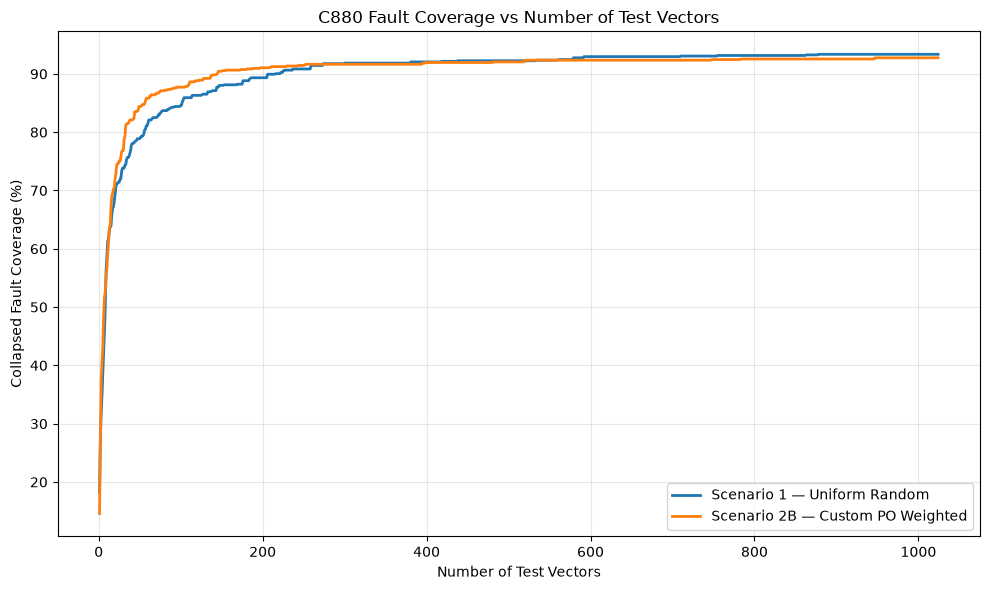

In [63]:
# ============================================================
# COVERAGE VS NUMBER OF VECTORS
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.plot(
    scenario1_coverage_df["vector_id"],
    scenario1_coverage_df[
        "fault_coverage_percent"
    ],
    label="Scenario 1 — Uniform Random",
    linewidth=2
)


plt.plot(
    scenario2b_coverage_df["vector_id"],
    scenario2b_coverage_df[
        "fault_coverage_percent"
    ],
    label="Scenario 2B — Custom PO Weighted",
    linewidth=2
)


plt.xlabel(
    "Number of Test Vectors"
)

plt.ylabel(
    "Collapsed Fault Coverage (%)"
)

plt.title(
    "C880 Fault Coverage vs Number of Test Vectors"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


In [64]:
# ============================================================
# COVERAGE AT SELECTED VECTOR COUNTS
# ============================================================

checkpoints = [
    1,
    10,
    25,
    50,
    100,
    250,
    500,
    750,
    1024
]


def coverage_at_vectors(
    coverage_df,
    checkpoints
):

    results = []

    coverage_df = coverage_df.sort_values(
        "vector_id"
    )

    for n in checkpoints:

        rows = coverage_df[
            coverage_df["vector_id"] <= n
        ]

        if len(rows) == 0:
            coverage = np.nan
        else:
            coverage = rows.iloc[-1][
                "fault_coverage_percent"
            ]

        results.append(coverage)

    return results


s1_values = coverage_at_vectors(
    scenario1_coverage_df,
    checkpoints
)

s2b_values = coverage_at_vectors(
    scenario2b_coverage_df,
    checkpoints
)


checkpoint_comparison = pd.DataFrame({

    "Vectors": checkpoints,

    "Scenario 1 Coverage (%)":
        s1_values,

    "Scenario 2B Coverage (%)":
        s2b_values
})


checkpoint_comparison[
    "2B Improvement (points)"
] = (
    checkpoint_comparison[
        "Scenario 2B Coverage (%)"
    ]
    -
    checkpoint_comparison[
        "Scenario 1 Coverage (%)"
    ]
)


display(
    checkpoint_comparison
)


,Vectors,Scenario 1 Coverage (%),Scenario 2B Coverage (%),2B Improvement (points)
0,1,18.309859,14.587525,-3.722334
1,10,58.953722,56.639839,-2.313883
2,25,71.428571,75.050302,3.621730
3,50,78.873239,84.406439,5.533199
4,100,84.607646,87.726358,3.118712
5,250,90.845070,91.448692,0.603622
6,500,92.253521,92.052314,-0.201207
7,750,93.058350,92.454728,-0.603622
8,1024,93.360161,92.756539,-0.603622


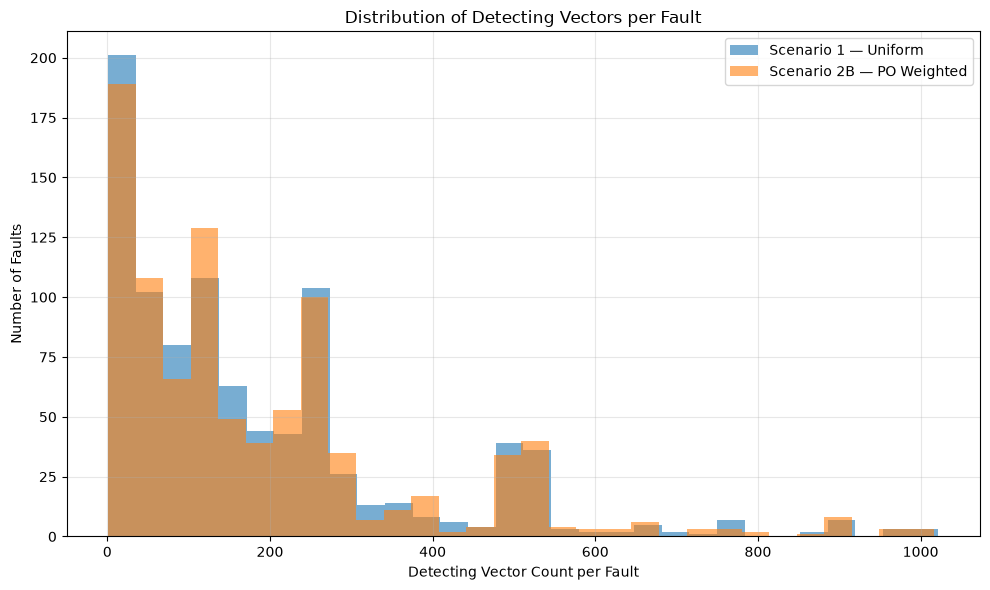

In [65]:
# ============================================================
# DETECTING VECTOR DISTRIBUTION
# ============================================================

plt.figure(
    figsize=(10, 6)
)


plt.hist(
    scenario1_fault_summary_df.loc[
        scenario1_fault_summary_df["detected"] == True,
        "detecting_vector_count"
    ],
    bins=30,
    alpha=0.6,
    label="Scenario 1 — Uniform"
)


plt.hist(
    scenario2b_fault_summary_df.loc[
        scenario2b_fault_summary_df["detected"] == True,
        "detecting_vector_count"
    ],
    bins=30,
    alpha=0.6,
    label="Scenario 2B — PO Weighted"
)


plt.xlabel(
    "Detecting Vector Count per Fault"
)

plt.ylabel(
    "Number of Faults"
)

plt.title(
    "Distribution of Detecting Vectors per Fault"
)

plt.grid(
    True,
    alpha=0.3
)

plt.legend()

plt.tight_layout()

plt.show()


In [66]:
# ============================================================
# FAULT-BY-FAULT COMPARISON
# ============================================================

s1_faults = (
    scenario1_fault_summary_df[
        [
            "fault_id",
            "fault",
            "detected",
            "detecting_vector_count",
            "first_detecting_vector",
            "total_po_mismatches"
        ]
    ]
    .copy()
)


s1_faults = s1_faults.rename(
    columns={
        "detected":
            "s1_detected",

        "detecting_vector_count":
            "s1_detecting_vectors",

        "first_detecting_vector":
            "s1_first_detected",

        "total_po_mismatches":
            "s1_po_mismatches"
    }
)


s2b_faults = (
    scenario2b_fault_summary_df[
        [
            "fault_id",
            "detected",
            "detecting_vector_count",
            "first_detecting_vector",
            "total_po_mismatches"
        ]
    ]
    .copy()
)


s2b_faults = s2b_faults.rename(
    columns={
        "detected":
            "s2b_detected",

        "detecting_vector_count":
            "s2b_detecting_vectors",

        "first_detecting_vector":
            "s2b_first_detected",

        "total_po_mismatches":
            "s2b_po_mismatches"
    }
)


fault_comparison = s1_faults.merge(
    s2b_faults,
    on="fault_id",
    how="outer"
)


fault_comparison[
    "detection_improved"
] = (
    (~fault_comparison["s1_detected"])
    &
    (fault_comparison["s2b_detected"])
)


fault_comparison[
    "detection_lost"
] = (
    (fault_comparison["s1_detected"])
    &
    (~fault_comparison["s2b_detected"])
)


fault_comparison[
    "detecting_vector_change"
] = (
    fault_comparison[
        "s2b_detecting_vectors"
    ]
    -
    fault_comparison[
        "s1_detecting_vectors"
    ]
)


fault_comparison[
    "po_mismatch_change"
] = (
    fault_comparison[
        "s2b_po_mismatches"
    ]
    -
    fault_comparison[
        "s1_po_mismatches"
    ]
)


display(
    fault_comparison.head(20)
)


,fault_id,fault,s1_detected,s1_detecting_vectors,s1_first_detected,s1_po_mismatches,s2b_detected,s2b_detecting_vectors,s2b_first_detected,s2b_po_mismatches,detection_improved,detection_lost,detecting_vector_change,po_mismatch_change
0,1,1->269/SA1,True,63,17.0,63,True,64,7.0,64,False,False,1,1
1,2,1->270/SA1,True,63,5.0,63,True,56,3.0,56,False,False,-7,-7
2,3,1->276/SA1,True,137,5.0,222,True,120,1.0,203,False,False,-17,-19
3,4,1->279/SA1,True,33,17.0,61,True,32,7.0,54,False,False,-1,-7
4,5,1->280/SA1,True,22,71.0,26,True,19,17.0,23,False,False,-3,-3
5,6,1->483/SA1,True,327,1.0,524,True,319,1.0,549,False,False,-8,25
6,7,1/SA0,True,392,9.0,829,True,400,11.0,837,False,False,8,8
7,8,1/SA1,True,410,1.0,872,True,390,1.0,849,False,False,-20,-23
8,9,101->303/SA1,True,249,7.0,249,True,253,9.0,253,False,False,4,4
9,10,101->304/SA0,True,247,6.0,247,True,249,2.0,249,False,False,2,2


In [67]:
# ============================================================
# FAULTS DETECTED BY 2B BUT NOT SCENARIO 1
# ============================================================

newly_detected_by_2b = (
    fault_comparison[
        fault_comparison[
            "detection_improved"
        ]
    ]
    .sort_values("fault_id")
)


print(
    f"Faults newly detected by 2B: "
    f"{len(newly_detected_by_2b)}"
)


display(
    newly_detected_by_2b
)


Faults newly detected by 2B: 3


,fault_id,fault,s1_detected,s1_detecting_vectors,s1_first_detected,s1_po_mismatches,s2b_detected,s2b_detecting_vectors,s2b_first_detected,s2b_po_mismatches,detection_improved,detection_lost,detecting_vector_change,po_mismatch_change
430,431,42->284/SA1,False,0,NaN,0,True,1,481.0,1,True,False,1,1
503,504,478/SA0,False,0,NaN,0,True,1,748.0,1,True,False,1,1
804,805,73/SA1,False,0,NaN,0,True,1,783.0,1,True,False,1,1


In [68]:
# ============================================================
# FAULTS DETECTED BY SCENARIO 1 BUT NOT 2B
# ============================================================

lost_by_2b = (
    fault_comparison[
        fault_comparison[
            "detection_lost"
        ]
    ]
    .sort_values("fault_id")
)


print(
    f"Faults detected by Scenario 1 "
    f"but missed by 2B: "
    f"{len(lost_by_2b)}"
)


display(
    lost_by_2b
)


Faults detected by Scenario 1 but missed by 2B: 9


,fault_id,fault,s1_detected,s1_detecting_vectors,s1_first_detected,s1_po_mismatches,s2b_detected,s2b_detecting_vectors,s2b_first_detected,s2b_po_mismatches,detection_improved,detection_lost,detecting_vector_change,po_mismatch_change
88,89,159->522/SA1,True,3,206.0,3,False,0,NaN,0,False,True,-3,-3
95,96,165->523/SA1,True,1,206.0,1,False,0,NaN,0,False,True,-1,-1
147,148,201->529/SA1,True,3,206.0,3,False,0,NaN,0,False,True,-3,-3
249,250,284/SA1,True,1,206.0,1,False,0,NaN,0,False,True,-1,-1
373,374,369->489/SA0,True,1,104.0,1,False,0,NaN,0,False,True,-1,-1
374,375,369->490/SA0,True,1,104.0,3,False,0,NaN,0,False,True,-1,-3
562,563,524/SA0,True,1,206.0,1,False,0,NaN,0,False,True,-1,-1
743,744,68->284/SA1,True,1,381.0,3,False,0,NaN,0,False,True,-1,-3
792,793,72/SA1,True,2,418.0,5,False,0,NaN,0,False,True,-2,-5


In [69]:
# ============================================================
# SAVE SCENARIO COMPARISON
# ============================================================

scenario_comparison.to_csv(
    "c880_scenario1_vs_scenario2b_comparison.csv",
    index=False
)


checkpoint_comparison.to_csv(
    "c880_scenario1_vs_scenario2b_coverage_checkpoints.csv",
    index=False
)


fault_comparison.to_csv(
    "c880_scenario1_vs_scenario2b_fault_comparison.csv",
    index=False
)


print(
    "Comparison files saved successfully."
)


Comparison files saved successfully.
